#  음용수 적합성 검증 
    - 문제 정의 : 다양한 수질 지표를 통해 검증
### 필수 포함 내용 
    - 상데 EDA 시각화 결과 
    - 평가 지표 수치 출력
    - 실제값 대비 예측 결과 시각화 ( 산점도 / 혼동행렬 / ROC (선택사항) )
    - input으로 입력 받아 결과 출력

- ph 수소이온농도(pH) (실수형)

    - 물의 산성도 또는 알칼리성도를측정하는지표

- Hardness 경도 (실수형)

    - 물속에 녹아 있는 칼슘(Calcium) 및 마그네슘(Magnesium) 성분의 양

- Solids 총 용존 고형물 (실수형)

    - 물에 녹아 있는 유기물 및 무기 화합물의총 농도


- Chloramines 클로라민 (실수형)

    - 물을 소독하기위해 사용된 염소(Chlorine)와 암모니아(Ammonia)의 잔류 결합물 농도

- Sulfate 황산염 (실수형)

    -  물속에 용해되어있는 황산 이온 성분으로, 지각이나대기등에서 자연적으로유입되는물질

- Conductivity 전기 전도도 (실수형)

    - 물이 전류를 통과시키는전도 능력을 수치화

- Organic_carbon 총 유기 탄소량 (실수형)

    - 물속에 녹아 있는 유기 화합물에포함된 총 탄소의 양
 
- Trihalomethanes 트리할로메탄 실수형 염소 소독 시 수중 유기물과염소가 반응하여생기는 발암성의심 소독부산물수치

- Turbidity 탁도 실수형 물에 떠다니는미세 입자나 부유 물질 때문에 물이 흐려보이는 정도를 나타내는지표

- Potability 음용 적합성 범주형 예측 목표(Target) 변수

    - 0 : 음용 불가능
    - 1 : 음용 가능

In [12]:
# 데이터 분석 
import pandas as pd
import numpy as np

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split 

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [13]:
raw_df = pd.read_csv('./data/water_potability.csv' , index_col = False , encoding = "utf-8-sig")

In [14]:
raw_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


#### 데이터 구조 확인

In [15]:
raw_df.shape

(3276, 10)

In [16]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [17]:
raw_df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [18]:
raw_df['Pot'] = raw_df['Potability'].map({
    0 : '음용 불가능',
    1 : '음용 가능'})

Potability 클래스 분포 countplot 확인

C:\Users\cyj01\AppData\Local\Temp\ipykernel_15408\484791653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = raw_df , x = 'Pot',palette = 'colorblind')


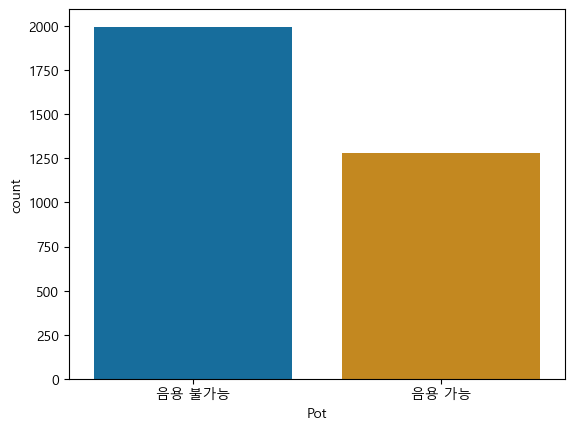

In [19]:
sns.countplot(data = raw_df , x = 'Pot',palette = 'colorblind')
plt.show()

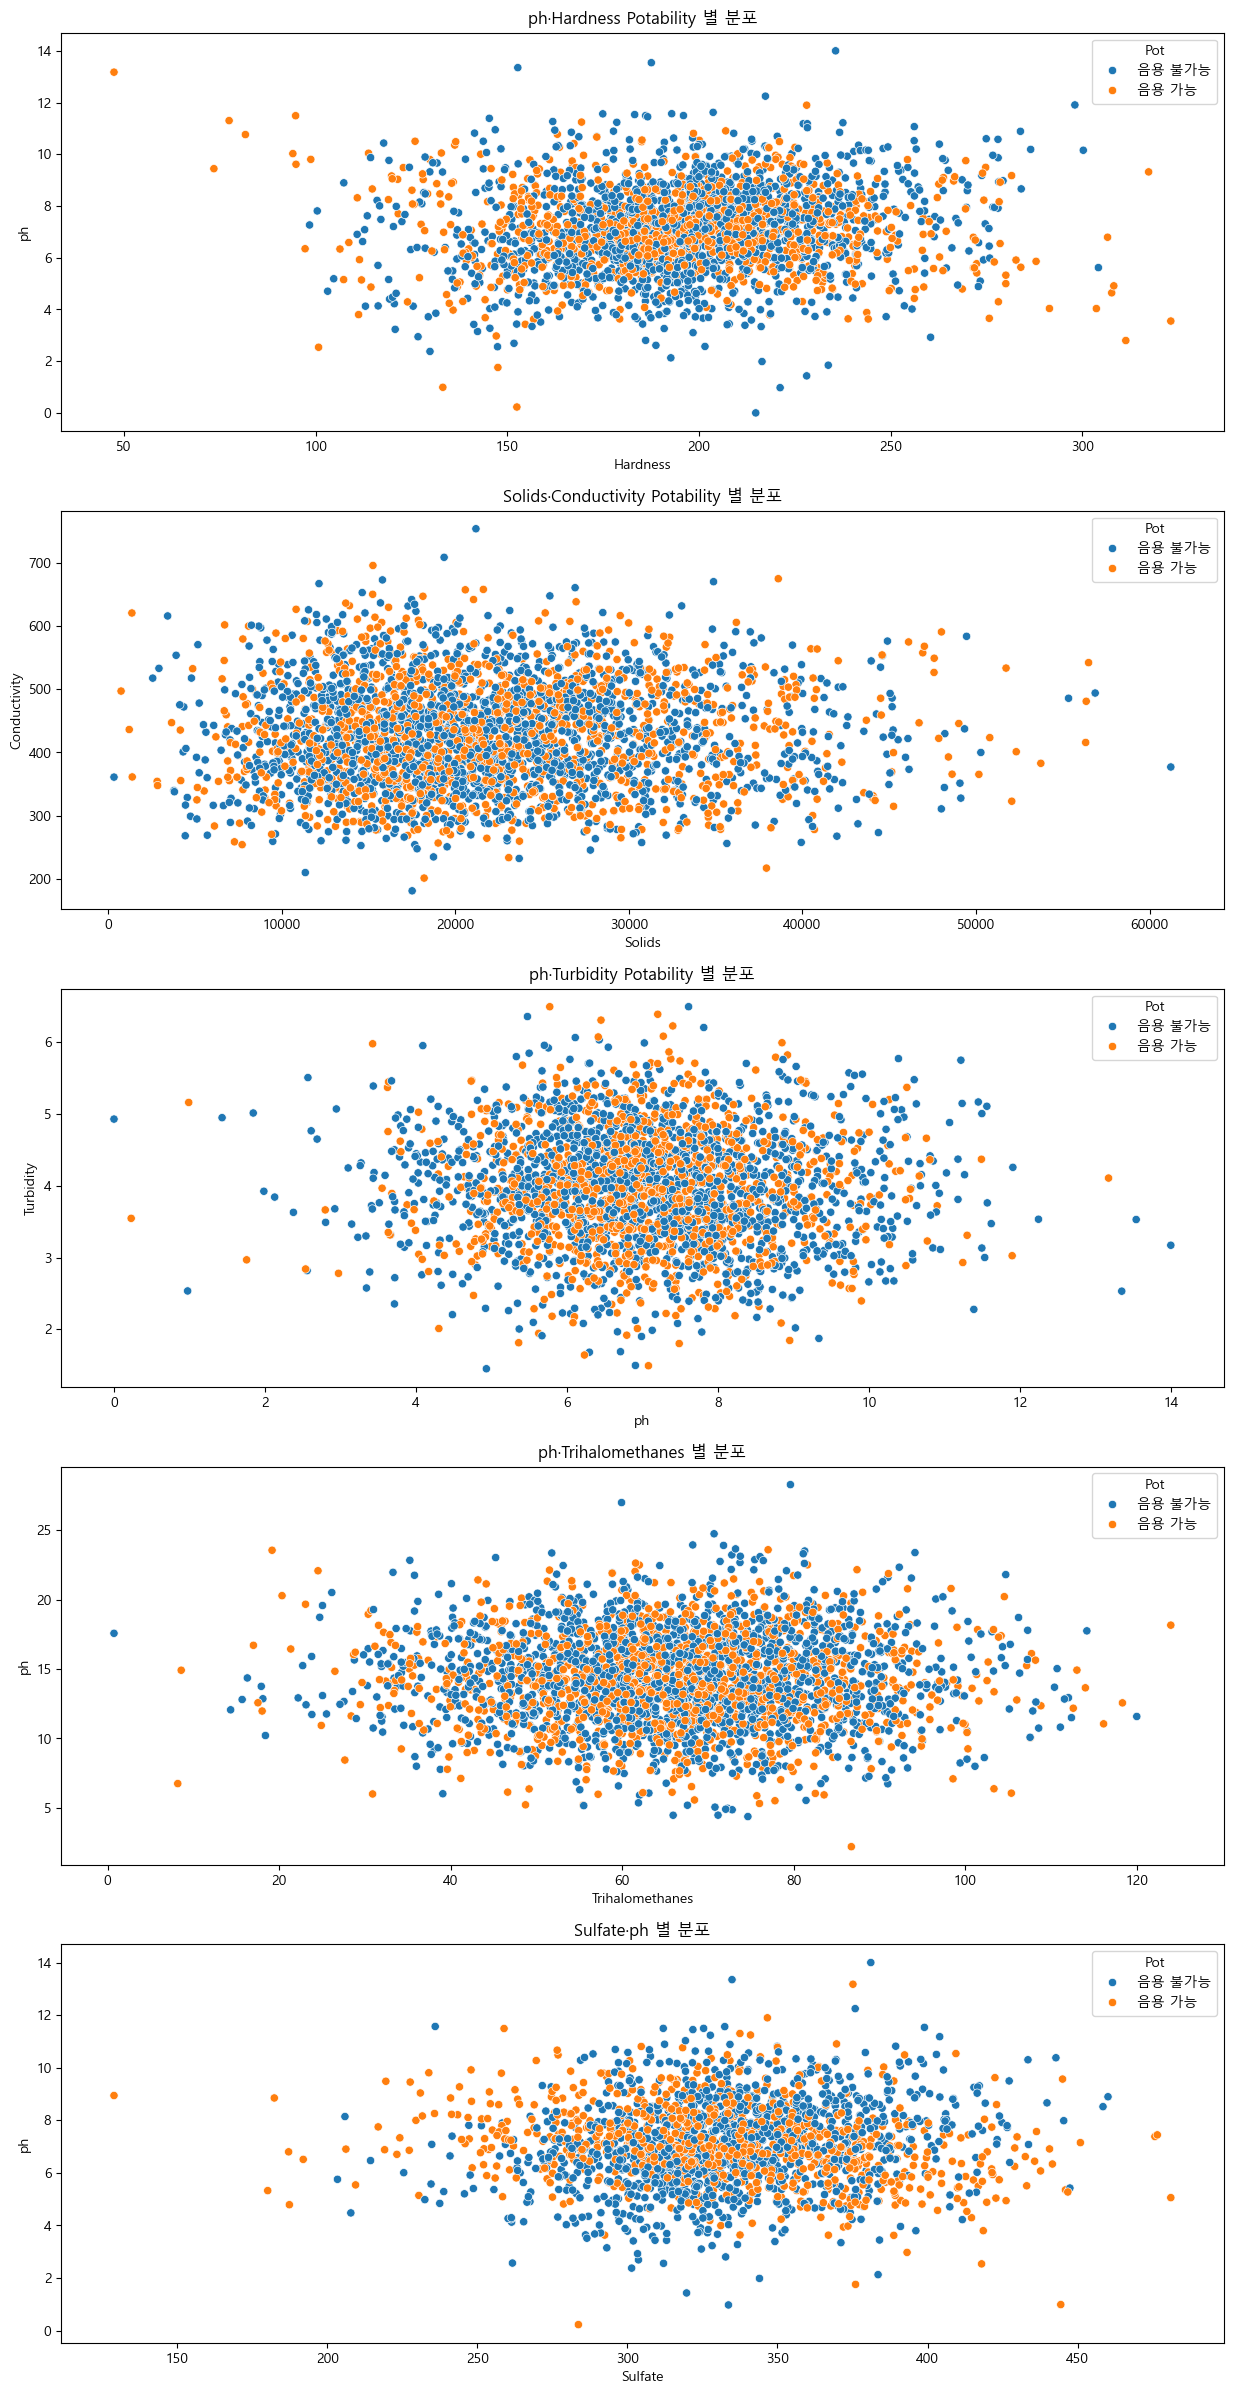

In [20]:
fig, ((ax1),(ax2),(ax3),(ax4),(ax5)) = plt.subplots(nrows = 5 , ncols = 1)

fig.set_size_inches(15,30)   # 전체 plot 사이즈 

ax1.set(xlabel = 'Hardness' , ylabel = 'ph' , title = 'ph·Hardness Potability 별 분포')
sns.scatterplot(data=raw_df,x='Hardness',y='ph',hue = 'Pot',ax=ax1)
    
ax2.set(xlabel = 'Solids' , ylabel = 'Conductivity' , title = 'Solids·Conductivity Potability 별 분포')
sns.scatterplot(data=raw_df,x='Solids',y='Conductivity',hue = 'Pot',ax=ax2)

ax3.set(xlabel = 'ph' , ylabel = 'Turbidity' , title = 'ph·Turbidity Potability 별 분포')
sns.scatterplot(data=raw_df,x='ph',y='Turbidity',hue = 'Pot',ax=ax3)

ax4.set(xlabel = 'Trihalomethanes' , ylabel = 'ph' , title = 'ph·Trihalomethanes 별 분포')
sns.scatterplot(data=raw_df,x='Trihalomethanes',y='Organic_carbon',hue = 'Pot',ax=ax4)

ax5.set(xlabel = 'Sulfate' , ylabel = 'ph' , title = 'Sulfate·ph 별 분포')
sns.scatterplot(data=raw_df,x='Sulfate',y='ph',hue = 'Pot',ax=ax5)

plt.show()

- 데이터 인사이트
- ph 7 부근에서 음용이 가능한 경향이 다수 관찰됨 , 중성수는 음용이 가능할것으로 예상
- Hardness는 유의미한 관측이 보이지 않음
- 모든 지표 데이터에서 이상치가 관측되는 경향이 있음 , 그러나 음용가능하므로 관찰 대상 

#### 결측치 확인

In [21]:
raw_df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
Pot                  0
dtype: int64

In [23]:
df = raw_df.copy()

ph, Sulfate , Trihalomethanes 에서 결측치 발견 - 중앙값 처리

In [24]:
df.fillna(df['ph'].median(),inplace = True)
df.fillna(df['Sulfate'].median(),inplace = True)
df.fillna(df['Trihalomethanes'].median(),inplace = True)

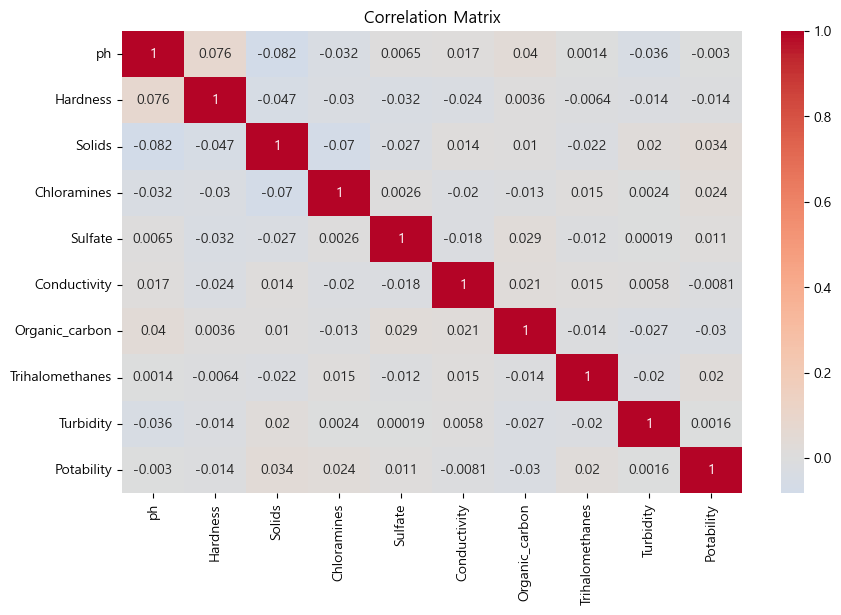

In [25]:
corr_df = df.drop(['Pot'],axis=1)
correlation_matrix = corr_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

### 중복치 처리 

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability', 'Pot'],
      dtype='object')

In [28]:
# 이상치 확인 대상 컬럼들
out_cols = df.drop(['Potability','Pot'], axis = 1).columns

outlier_list = []

# 컬럼별 IQR값 확인
for col in out_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_rate = (len(outliers) / len(df)) * 100

    outlier_list.append({
        "컬럼명": col,
        "Q1":Q1,
        "Q3":Q3,
        "IQR":IQR,
        "하한값":lower,
        "상한값":upper,
        "이상치 개수":len(outliers),
        "이상치 비율(%)":outlier_rate
    })

# 데이터프레임으로 변환
outlier_df = pd.DataFrame(outlier_list)
outlier_df

,컬럼명,Q1,Q3,IQR,하한값,상한값,이상치 개수,이상치 비율(%)
0,ph,6.277673,7.870050,1.592377,3.889107,10.258615,142,4.334554
1,Hardness,176.850538,216.667456,39.816918,117.125160,276.392834,83,2.533578
2,Solids,15666.690297,27332.762127,11666.071830,-1832.417449,44831.869873,47,1.434676
3,Chloramines,6.127421,8.114887,1.987466,3.146221,11.096086,61,1.862027
4,Sulfate,240.722848,350.385756,109.662908,76.228485,514.880119,781,23.840049
5,Conductivity,365.734414,481.792304,116.057890,191.647579,655.879140,11,0.335775
6,Organic_carbon,12.065801,16.557652,4.491850,5.328026,23.295427,25,0.763126
7,Trihalomethanes,53.793688,76.666609,22.872921,19.484306,110.975991,187,5.708181
8,Turbidity,3.439711,4.500320,1.060609,1.848797,6.091233,19,0.579976


### 이상치 처리

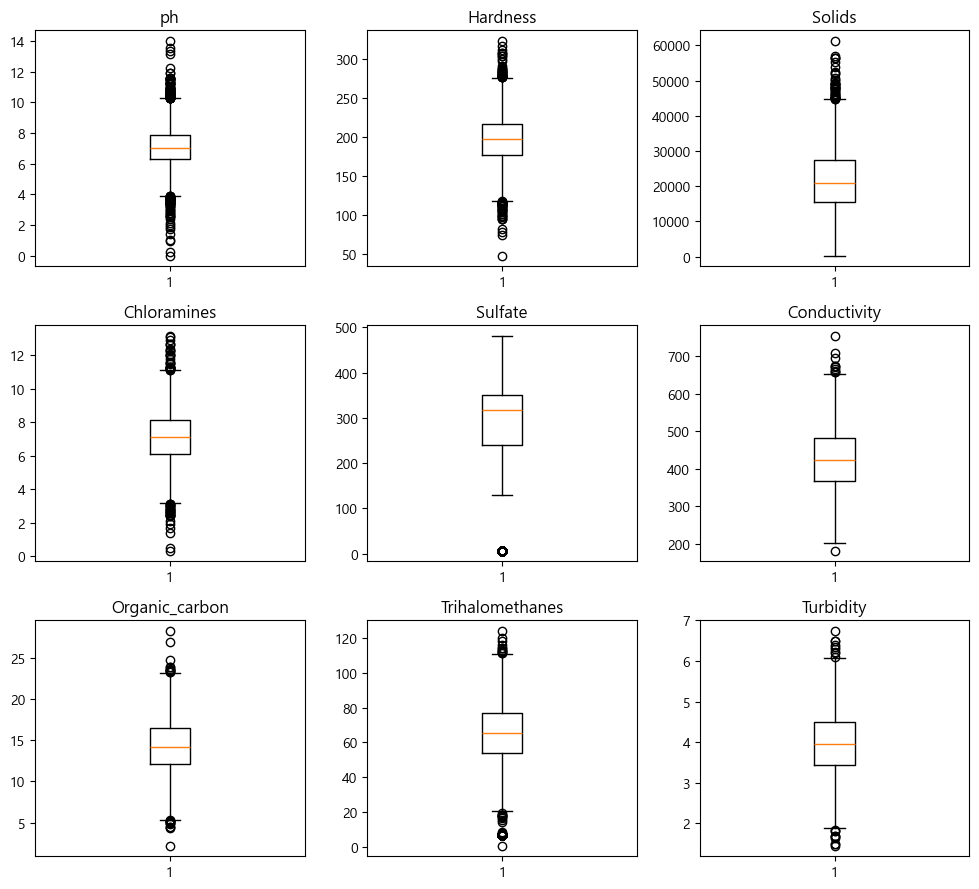

In [29]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(nrows = 3 , ncols = 3)

fig.set_size_inches(10,9)   # 전체 plot 사이즈 

ax1.set(title = 'ph')
ax1.boxplot(df['ph'])
ax2.set(title = 'Hardness')
ax2.boxplot(df['Hardness'])
ax3.set(title = 'Solids')
ax3.boxplot(df['Solids'])
ax4.set(title = 'Chloramines')
ax4.boxplot(df['Chloramines'])
ax5.set(title = 'Sulfate')
ax5.boxplot(df['Sulfate'])
ax6.set(title = 'Conductivity')
ax6.boxplot(df['Conductivity'])
ax7.set(title = 'Organic_carbon')
ax7.boxplot(df['Organic_carbon'])
ax8.set(title = 'Trihalomethanes')
ax8.boxplot(df['Trihalomethanes'])
ax9.set(title = 'Turbidity')
ax9.boxplot(df['Turbidity'])

plt.tight_layout()
plt.show()

In [30]:
numeric_cols = df.select_dtypes(include=['number']).columns
drink_averages = df.groupby("Potability")[numeric_cols].mean()
print("음용별 숫자형 변수 평균:\n{}".format(drink_averages))

음용별 숫자형 변수 평균:
                  ph    Hardness        Solids  Chloramines     Sulfate  \
Potability                                                                
0           7.077736  196.733292  21777.490788     7.092175  254.567574   
1           7.068655  195.800744  22383.991018     7.169338  257.934471   

            Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
Potability                                                             
0             426.730454       14.364335        63.129607   3.965800   
1             425.383800       14.160893        63.978916   3.968328   

            Potability  
Potability              
0                  0.0  
1                  1.0  


In [31]:
X = df.drop(['Potability','Pot'],axis=1)

y = df['Potability']

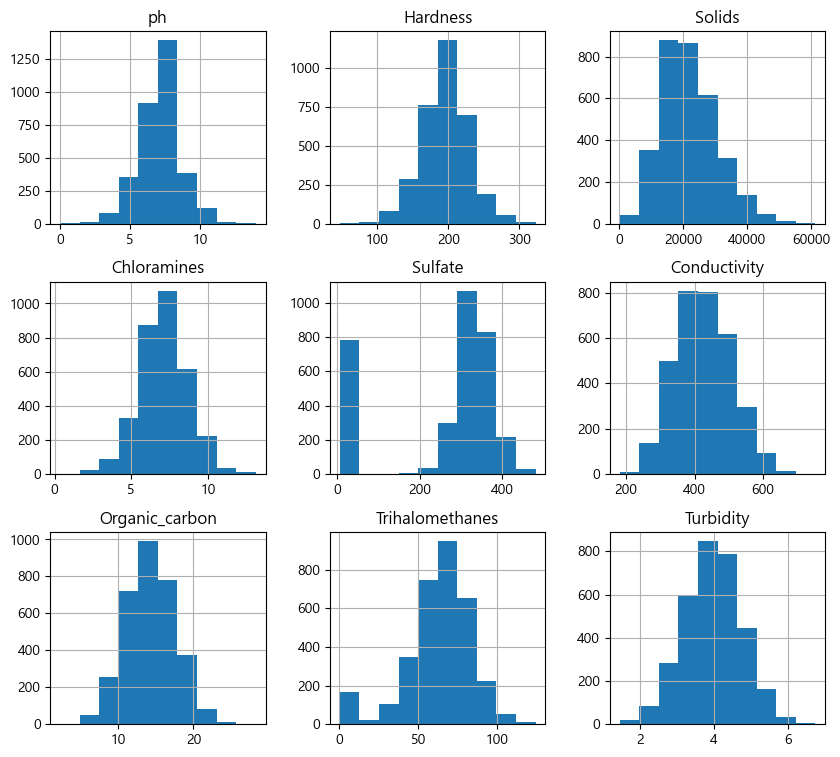

In [32]:
X.hist(figsize=(10,9))
plt.show()

독립/종속(Potability) 분리

In [36]:
feature_names = X.columns.unique()
target_names = df['Pot'].unique()

Train/Test 분할

In [37]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y
)

표준화 스케일링 시행 

In [38]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train_scaled.mean().round(3)

np.float64(0.0)

In [40]:
X_train_scaled.std().round(3)

np.float64(1.0)

In [41]:
model = RandomForestClassifier(
    n_estimators=100, # Decision tree 100개 생성 
    max_depth=None,
    random_state= 42 # 기준점 통일
)

In [42]:
model.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = model.predict(X_test_scaled)

Accuracy,

In [44]:
accuracy = accuracy_score(y_test ,y_pred ) 
print("Random Forest 정확도 :" ,round(accuracy,2))

Random Forest 정확도 : 0.67


Confusion Matrix,

In [45]:
cm = confusion_matrix(y_test , y_pred)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 음용불가능','실제 음용가능'],
    columns = ['예측 음용불가능','예측 음용가능']
)
cm_df

,예측 음용불가능,예측 음용가능
실제 음용불가능,361,39
실제 음용가능,176,80


실제값 대비 예측값 시각

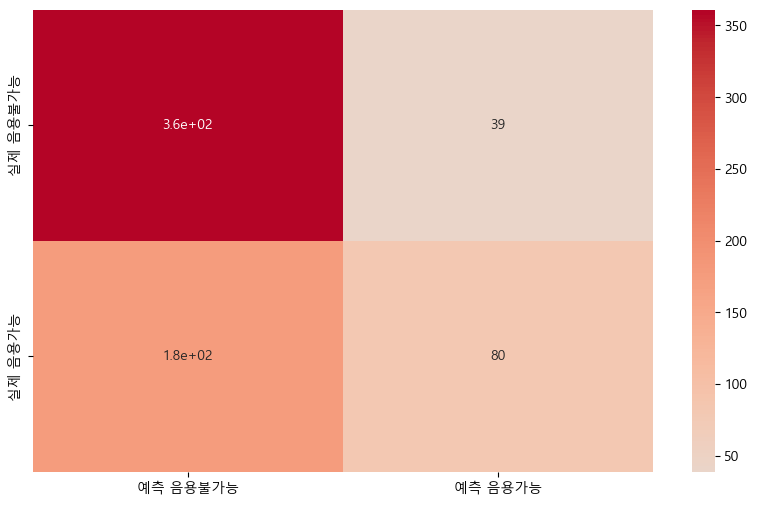

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm_df,annot=True,cmap="coolwarm",center=0)
plt.show()

classification_report

In [47]:
print(classification_report(
    y_test,
    y_pred,
    target_names = target_names))

              precision    recall  f1-score   support

      음용 불가능       0.67      0.90      0.77       400
       음용 가능       0.67      0.31      0.43       256

    accuracy                           0.67       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.67      0.67      0.64       656



In [48]:
importance = pd.DataFrame({
    'feature': feature_names,
    'importance' : model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

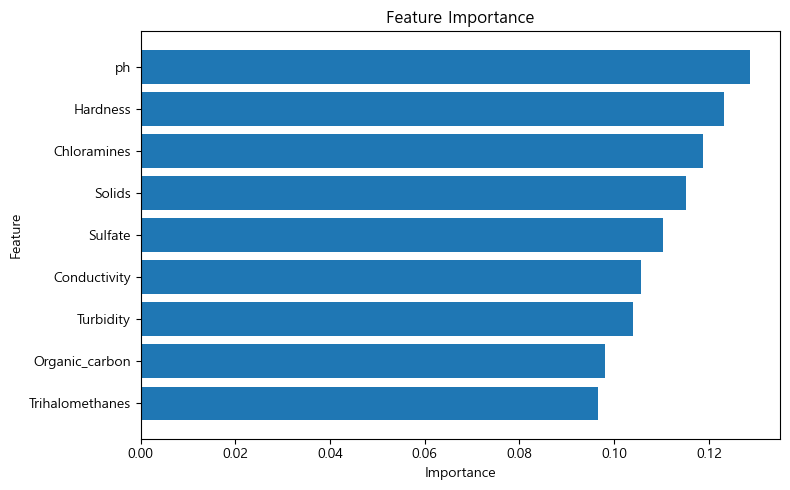

In [49]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
ph = float(input("ph ( 수소이온 농도 ) : "))
Hardness = float(input("Hardness ( 경도 ) : "))
Solids = float(input("Solids ( 총 용존 고형물 ): "))
Chloramines = float(input("Chloramines ( 클로라민 ): "))
Sulfate = float(input("Sulfate ( 황산염 ): "))
Conductivity = float(input("Conductivity ( 전기 전도도 ): "))
Organic_carbon = float(input("Organic_carbon ( 총 유기 탄소량 ) : "))
Trihalomethanes = float(input("Trihalomethanes ( 트리할로메탄 ) : "))
Turbidity = float(input("Turbidity ( 탁도 ) : "))

User_data = pd.DataFrame([
    [ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity]],
    columns = feature_names
)

pred = model.predict(User_data)
result = target_names[pred[0]]
print(f"결과는 {result} 입니다")